# 1. 모델 불러오기

In [1]:
import torch

print(torch.__version__)

2.10.0+cu126


In [2]:
from ultralytics import YOLO

model = YOLO('./models/yolo26n-seg.pt')

# 2. 예측하기

In [ ]:
image_url = "https://ultralytics.com/images/bus.jpg"

# results에는 항상 리스트가 담긴다.
results = model.predict(
    source=image_url,
    save = True,
    project = "myresult"
)


image 1/1 c:\Users\user\Documents\pj03\bus.jpg: 640x480 4 persons, 1 bus, 164.1ms
Speed: 9.4ms preprocess, 164.1ms inference, 48.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\user\Documents\pj03\runs\segment\myresult\predict


In [5]:
print(type(results))
print(len(results))

<class 'list'>
1


In [ ]:
# 출력 결과를 보고 어디에서 뭘 가져와야 하는지 생각
result = results[0]
result
# masks에 주목

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair

In [7]:
result.masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0

In [8]:
print(len(result.masks.data))

5


In [11]:
result.masks.data[0].shape
result.masks.data[0]
# 0: 검은색, 1: 하얀색

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0', dtype=torch.uint8)

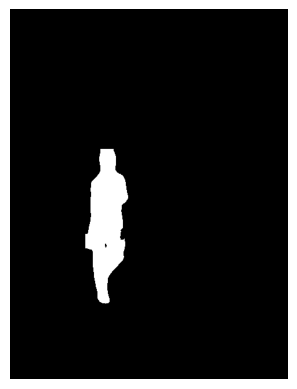

In [15]:
import matplotlib.pyplot as plt
idx = 3

plt.imshow(result.masks.data[idx].to("cpu"), cmap="gray")
plt.axis("off")
plt.show()

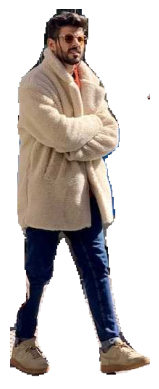

In [30]:
import numpy as np
from PIL import Image

idx = 0

# 1) 원본 이미지 numpy로 바꾸기
orig = Image.fromarray(result.orig_img[:,:,::-1])

# 2) 마스크, 원본 이미지 사이즈로 리사이즈
masks = result.masks
mask = masks.data[idx].to("cpu").numpy()
mask_resized = Image.fromarray(
    (mask*255).astype(np.int8)).resize(
        (orig.width, orig.height),
        Image.NEAREST
    )

# 3) ALPHA 채널 추가 및 마스크 적용
orig_rgba = orig.convert("RGBA")
orig_array = np.array(orig_rgba)
orig_array[:,:,3] = np.array(mask_resized)
masked_img = Image.fromarray(orig_array)

# 4) 박스 크롭
x1, y1, x2, y2 = result.boxes.xyxy[idx].int().tolist()
crop_img = masked_img.crop((x1, y1, x2, y2))

# 5) 이미지 출력
plt.imshow(crop_img)
plt.axis("off")
plt.show()

# 코드의 역할
# 주의할 점

In [ ]:
result.boxes.cls    # cls = 예측값

tensor([0., 5., 0., 0., 0.], device='cuda:0')

In [34]:
names = result.names
print(names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [37]:
pred_idx_list = result.boxes.cls

for pred_idx in pred_idx_list:
    print(pred_idx)
    print(int(pred_idx.to("cpu")))
    print(names[int(pred_idx.to("cpu"))])
    print("="*50)

tensor(0., device='cuda:0')
0
person
tensor(5., device='cuda:0')
5
bus
tensor(0., device='cuda:0')
0
person
tensor(0., device='cuda:0')
0
person
tensor(0., device='cuda:0')
0
person


# FastSAM

## 1) 모델 불러오기

In [38]:
from ultralytics import FastSAM

model = FastSAM("./models/FastSAM-s.pt")
model

FastSAM(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_run

## 2) 예측하기

In [ ]:
source = "./images/test_image.jpg"

results = model.predict(
    source = source,
    save = True,
    project = "myresult"
)


image 1/1 c:\Users\user\Documents\pj03\images\test_image.jpg: 384x640 93 objects, 105.6ms
Speed: 4.2ms preprocess, 105.6ms inference, 178.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\user\Documents\pj03\runs\segment\myresult\predict2


In [40]:
print(type(results))
print(len(results))

<class 'list'>
1


In [41]:
result = results[0]

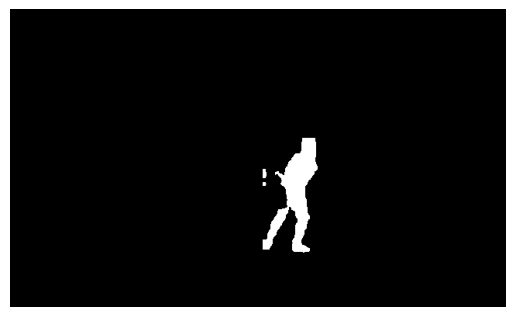

In [44]:
import matplotlib.pyplot as plt
idx = 10

plt.imshow(result.masks.data[idx].to("cpu"), cmap="gray")
plt.axis("off")
plt.show()

## 3) 텍스트와 이미지로 예측하기

In [61]:
source = "./images/dog.jpeg"

results = model.predict(
    source = source,
    texts = "a photo of a dog",
    save = True,
    project = "myresult"
)


image 1/1 c:\Users\user\Documents\pj03\images\dog.jpeg: 640x384 1 object, 79.5ms
Speed: 4.2ms preprocess, 79.5ms inference, 875.0ms postprocess per image at shape (1, 3, 640, 384)
Results saved to C:\Users\user\Documents\pj03\runs\segment\myresult\predict4


In [62]:
result = results[0]
print(len(result.masks.data))

1


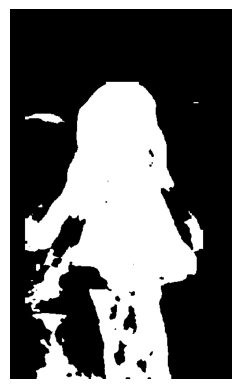

In [63]:
import matplotlib.pyplot as plt
idx = 0

plt.imshow(result.masks.data[idx].to("cpu"), cmap="gray")
plt.axis("off")
plt.show()

# SAM3

In [ ]:
# 무겁고 성능이 좋은 모델은 매번 깃허브와 문서를 확인해서 설치 하는 습관을 들인다.
# 유료 모델, 동의를 받는 모델(gated model?)
# uv add python-dotenv huggingface_hub

In [65]:
from dotenv import load_dotenv

load_dotenv()

True

## 1) 허깅페이스 로그인

In [66]:
from huggingface_hub import login
import os

login(token=os.getenv("HUGGINGFACE_TOKEN"))

## 2) 허깅페이스에서 모델 다운로드

In [68]:
from huggingface_hub import hf_hub_download 

hf_hub_download(
    repo_id="facebook/sam3",
    filename="sam3.pt",
    local_dir="./models",
    token=os.getenv("HUGGINFACE_TOKEN")
)

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

'models\\sam3.pt'

## 3) 예측하기

In [77]:
from ultralytics.models.sam import SAM3SemanticPredictor

overrides = dict(
    conf = 0.25,
    task = "segment",
    mode = "predict",
    model = "./models/sam3.pt",
    half = True,
    save = True,
)

predictor = SAM3SemanticPredictor(overrides=overrides)

In [83]:
# 이미지 설정
predictor.set_image("./images/cat.jpg")

WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]


In [84]:
# 예측하기 1 - 한 개 추출
results = predictor(text=["cat"])


image 1/1 c:\Users\user\Documents\pj03\images\cat.jpg: 644x644 1 cat, 492.4ms
Speed: 5.5ms preprocess, 492.4ms inference, 2.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\user\Documents\pj03\runs\segment\predict


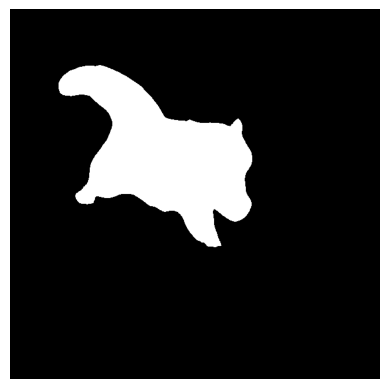

In [85]:
import matplotlib.pyplot as plt 
result = results[0]

idx = 0

plt.imshow(result.masks.data[idx].to("cpu"), cmap="gray")
plt.axis("off")
plt.show()

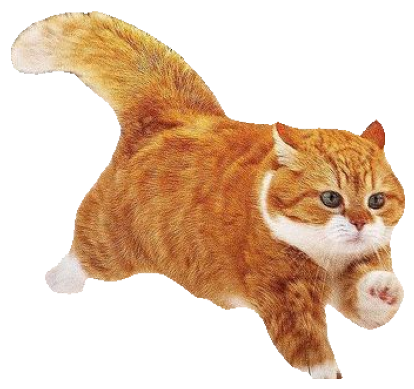

In [87]:
import numpy as np
from PIL import Image

idx = 0

# 1) 원본 이미지 numpy로 바꾸기
orig = Image.fromarray(result.orig_img[:,:,::-1])

# 2) 마스크, 원본 이미지 사이즈로 리사이즈
masks = result.masks
mask = masks.data[idx].to("cpu").numpy()
mask_resized = Image.fromarray(
    (mask*255).astype(np.int8)).resize(
        (orig.width, orig.height),
        Image.NEAREST
    )

# 3) ALPHA 채널 추가 및 마스크 적용
orig_rgba = orig.convert("RGBA")
orig_array = np.array(orig_rgba)
orig_array[:,:,3] = np.array(mask_resized)
masked_img = Image.fromarray(orig_array)

# 4) 박스 크롭
x1, y1, x2, y2 = result.boxes.xyxy[idx].int().tolist()
crop_img = masked_img.crop((x1, y1, x2, y2))

# 5) 이미지 출력
plt.imshow(crop_img)
plt.axis("off")
plt.show()

In [81]:
# 예측하기 2 - 여러개 추출
results = predictor(text=["person", "bus"])


image 1/1 c:\Users\user\Documents\pj03\images\test_image.jpg: 644x644 (no detections), 464.5ms
Speed: 8.1ms preprocess, 464.5ms inference, 1.8ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\user\Documents\pj03\runs\segment\predict


In [82]:
# 예측하기 3 - 묘사로 추출
results = predictor(
    text=["person with red cloth", "person with blue cloth"]
)


image 1/1 c:\Users\user\Documents\pj03\images\test_image.jpg: 644x644 3 person with red cloths, 3 person with blue cloths, 449.0ms
Speed: 8.5ms preprocess, 449.0ms inference, 3.1ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\user\Documents\pj03\runs\segment\predict
